Working directory successfully set to: /content/rbvm-capstone
Dataset successfully saved to: rbvm-capstone/data/raw_vulnerability_data.csv
Libraries successfully imported.
Dataset created and saved to 'raw_vulnerability_data.csv'. Shape: (5000, 10)
--- Initial Null Values ---
vulnerability_id        0
cve_id                  0
cvss_score            150
epss_score              0
cisa_kev_listed         0
asset_criticality       0
internet_facing         0
patch_availability      0
days_open               0
action_required         0
dtype: int64

Duplicate rows found: 0

--- Missing Values Post-Imputation ---
vulnerability_id      0
cve_id                0
cvss_score            0
epss_score            0
cisa_kev_listed       0
asset_criticality     0
internet_facing       0
patch_availability    0
days_open             0
action_required       0
dtype: int64


/tmp/ipykernel_509/3811430570.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='asset_criticality', y='risk_composite_score',
/tmp/ipykernel_509/3811430570.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='action_required', palette='Set2', ax=axes[1, 0])


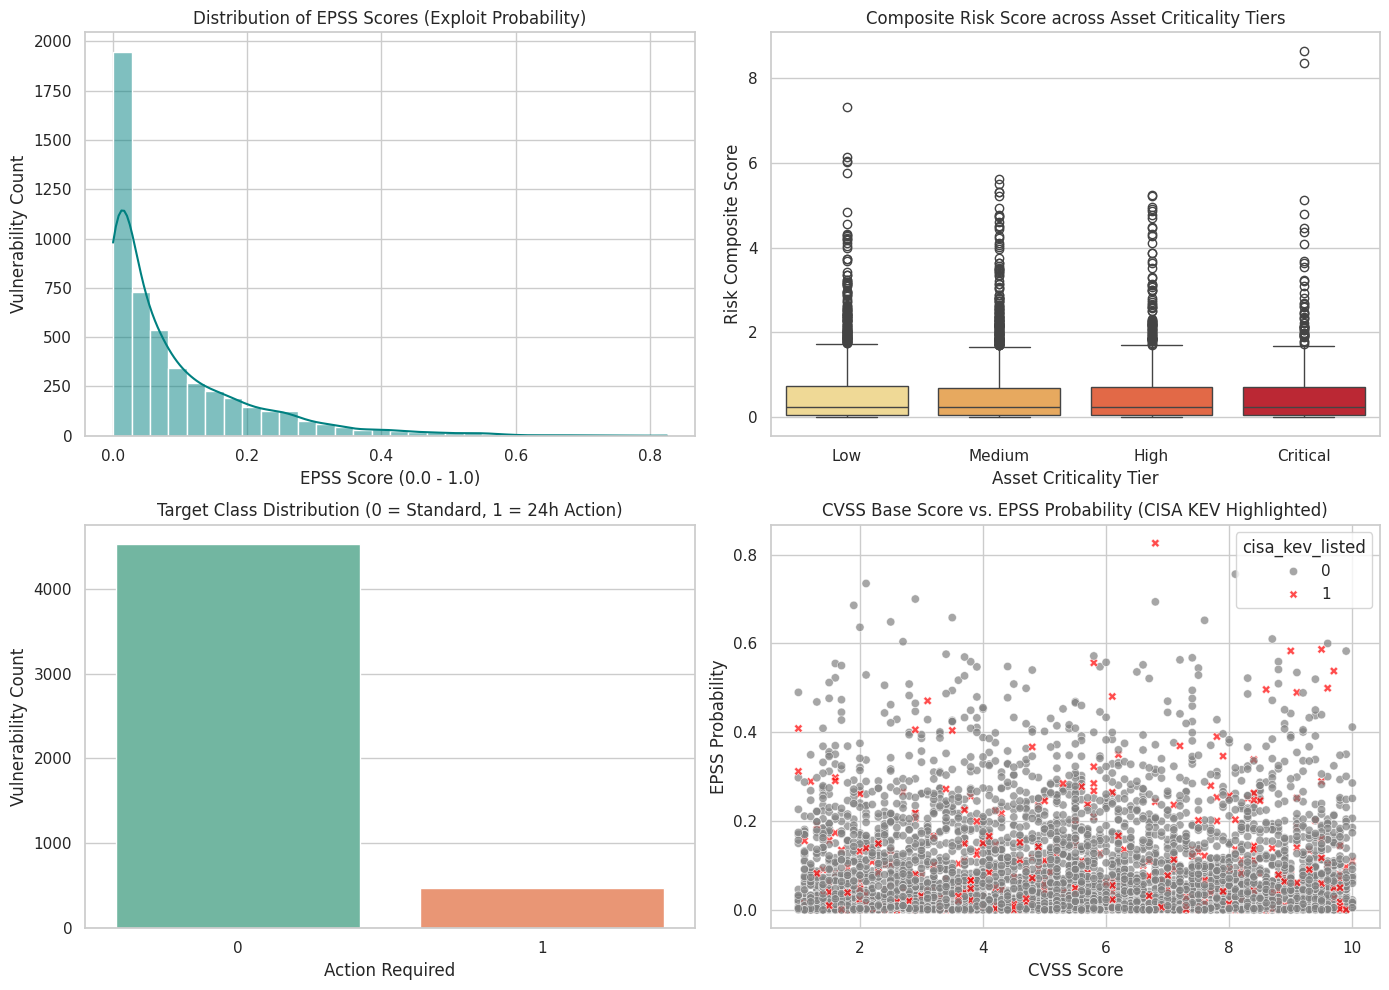

================ BASELINE MODEL PERFORMANCE ================
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       905
           1       0.98      0.94      0.96        95

    accuracy                           0.99      1000
   macro avg       0.99      0.97      0.98      1000
weighted avg       0.99      0.99      0.99      1000

ROC-AUC Score: 0.9794


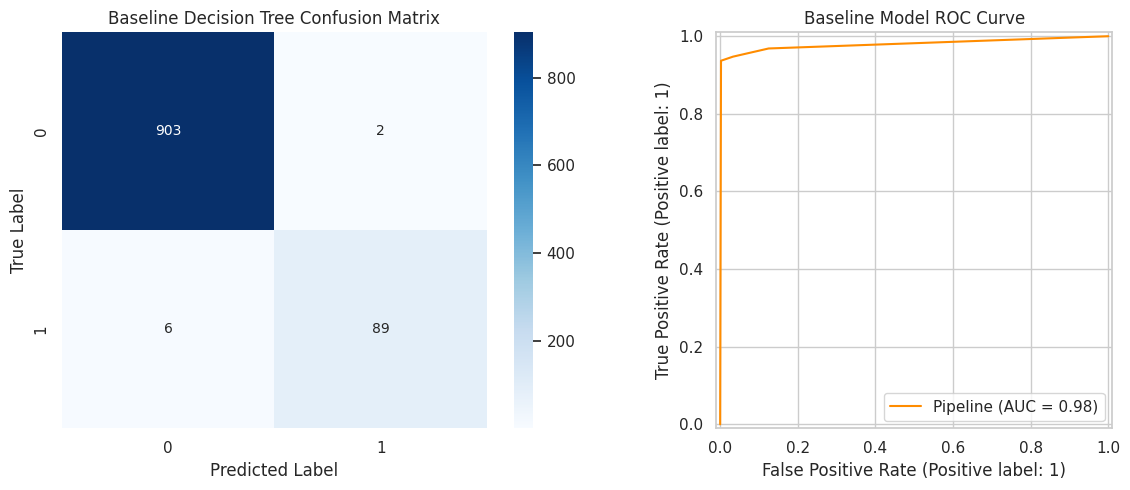

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, roc_auc_score

import os
from pathlib import Path

# Set project root path in Colab
PROJECT_ROOT = Path('/content/rbvm-capstone')

# Create standard repository subdirectories
(PROJECT_ROOT / 'data').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'notebooks').mkdir(parents=True, exist_ok=True)

# Set current working directory to project root
os.chdir(PROJECT_ROOT)

print(f"Working directory successfully set to: {os.getcwd()}")


print(f"Dataset successfully saved to: {file_path}")
# Configure visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Set seed for reproducibility
np.random.seed(42)
print("Libraries successfully imported.")
# Number of records to synthesize
n_samples = 5000

# Base feature creation
vulnerability_ids = [f"VULN-{10000 + i}" for i in range(n_samples)]
cve_ids = [f"CVE-2024-{np.random.randint(1000, 9999)}" for _ in range(n_samples)]
cvss_scores = np.round(np.random.uniform(1.0, 10.0, n_samples), 1)

# EPSS probability using Beta distribution (Corrected positional/keyword syntax)
epss_scores = np.random.beta(a=0.5, b=5.0, size=n_samples)

cisa_kev_listed = np.random.choice([1, 0], size=n_samples, p=[0.08, 0.92]) # ~8% in KEV catalog
asset_criticality = np.random.choice(['Low', 'Medium', 'High', 'Critical'], size=n_samples, p=[0.3, 0.4, 0.2, 0.1])
internet_facing = np.random.choice([1, 0], size=n_samples, p=[0.25, 0.75])
patch_availability = np.random.choice([1, 0], size=n_samples, p=[0.9, 0.1])
days_open = np.random.exponential(scale=45, size=n_samples).astype(int)

# Introduce realistic missing values (~3% missing CVSS scores due to scanner parsing dropouts)
cvss_scores_missing = cvss_scores.copy()
cvss_scores_missing[np.random.choice(n_samples, 150, replace=False)] = np.nan

# Define Target Variable: Action Required (1 = 24h SLA Required, 0 = Standard Patching Cycle)
action_required = np.where(
    (cisa_kev_listed == 1) |
    ((epss_scores > 0.35) & (np.isin(asset_criticality, ['High', 'Critical'])) & (internet_facing == 1)) |
    ((cvss_scores > 8.5) & (epss_scores > 0.2)), 1, 0
)

# Assemble DataFrame
df = pd.DataFrame({
    'vulnerability_id': vulnerability_ids,
    'cve_id': cve_ids,
    'cvss_score': cvss_scores_missing,
    'epss_score': epss_scores,
    'cisa_kev_listed': cisa_kev_listed,
    'asset_criticality': asset_criticality,
    'internet_facing': internet_facing,
    'patch_availability': patch_availability,
    'days_open': days_open,
    'action_required': action_required
})

# Save output to raw data directory
df.to_csv('data/raw_vulnerability_data.csv', index=False)
print("Dataset created and saved to 'raw_vulnerability_data.csv'. Shape:", df.shape)
# Inspect initial null count and data structure
print("--- Initial Null Values ---")
print(df.isnull().sum())

# Duplicate check
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()

# Targeted Median Imputation on CVSS score grouped by asset criticality
df['cvss_score'] = df.groupby('asset_criticality')['cvss_score'].transform(lambda x: x.fillna(x.median()))

print("\n--- Missing Values Post-Imputation ---")
print(df.isnull().sum())
# Feature 1: Exposure Weight Multiplier (1.5x for Internet Facing, 1.0x Internal)
exposure_weight = np.where(df['internet_facing'] == 1, 1.5, 1.0)
df['risk_composite_score'] = np.round(df['cvss_score'] * df['epss_score'] * exposure_weight, 3)

# Feature 2: High Threat Heuristic Flag
df['is_high_threat'] = np.where((df['cisa_kev_listed'] == 1) & (df['epss_score'] > 0.1), 1, 0)

# Feature 3: Asset Criticality Ordinal Encoding
criticality_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['asset_criticality_num'] = df['asset_criticality'].map(criticality_map)

df[['vulnerability_id', 'cvss_score', 'epss_score', 'risk_composite_score', 'asset_criticality_num']].head()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: EPSS Score Distribution
sns.histplot(df['epss_score'], kde=True, ax=axes[0, 0], color='teal', bins=30)
axes[0, 0].set_title('Distribution of EPSS Scores (Exploit Probability)')
axes[0, 0].set_xlabel('EPSS Score (0.0 - 1.0)')
axes[0, 0].set_ylabel('Vulnerability Count')

# Plot 2: Composite Risk Score by Asset Criticality
sns.boxplot(data=df, x='asset_criticality', y='risk_composite_score',
            order=['Low', 'Medium', 'High', 'Critical'], palette='YlOrRd', ax=axes[0, 1])
axes[0, 1].set_title('Composite Risk Score across Asset Criticality Tiers')
axes[0, 1].set_xlabel('Asset Criticality Tier')
axes[0, 1].set_ylabel('Risk Composite Score')

# Plot 3: Target Class Balance (Action Required)
sns.countplot(data=df, x='action_required', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Target Class Distribution (0 = Standard, 1 = 24h Action)')
axes[1, 0].set_xlabel('Action Required')
axes[1, 0].set_ylabel('Vulnerability Count')

# Plot 4: CVSS vs EPSS Scatter Highlighted by CISA KEV
sns.scatterplot(data=df, x='cvss_score', y='epss_score', hue='cisa_kev_listed',
                style='cisa_kev_listed', palette={0: 'gray', 1: 'red'}, alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('CVSS Base Score vs. EPSS Probability (CISA KEV Highlighted)')
axes[1, 1].set_xlabel('CVSS Score')
axes[1, 1].set_ylabel('EPSS Probability')

plt.tight_layout()
plt.show()
# Define Features (X) and Target (y)
X = df[['cvss_score', 'epss_score', 'cisa_kev_listed', 'asset_criticality',
        'internet_facing', 'patch_availability', 'days_open', 'risk_composite_score']]
y = df['action_required']

# Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Transformation Pipelines
numeric_features = ['cvss_score', 'epss_score', 'days_open', 'risk_composite_score']
categorical_features = ['asset_criticality']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

# Baseline Decision Tree Pipeline
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
])

# Train Baseline Model
baseline_model.fit(X_train, y_train)

# Model Predictions
y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

# Output Baseline Performance Metrics
print("================ BASELINE MODEL PERFORMANCE ================")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Baseline Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve Display
RocCurveDisplay.from_estimator(baseline_model, X_test, y_test, ax=axes[1], color='darkorange')
axes[1].set_title('Baseline Model ROC Curve')

plt.tight_layout()
plt.show()
